<h3><b>Introduction to Data Analytics - Exercise set 5 - data processing and management</b></h3>

Put all your exercises (Jupyter Notebooks or Python-files) in your course Git-project.<br /><br />
<span style="font-weight: bold;">Use either code comments or Jupyter Notebook markdown (text) to document which exercise you are doing and what a certain code section does!</span><br />

<span style="font-weight: bold;">Remember: your Jupyter notebook's clarity (how easy it is to read and understand) also affects your scoring!</span><br /><br />
<span style="font-weight: bold;">Remember also: 
<span style="font-weight: bold;">If you use generative AI in any part of any exercise, 
MENTION IT CLEARLY! </span><br />
<span style="font-weight: bold;">(code comments are enough, also mention the prompts used).</span><br /><br />
See also the materials discussing the usage of AI in this course!</span><br /><br />


You can return all of these exercises in a single Jupyter Notebook, if you wish.

<p style="color: red;"><b>NOTE: The JSON/XML –files in Moodle in these exercises have been randomly generated. In other words, the data doesn't make any sense!</b></p>

In [738]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import requests
import json


<h4><b>1. </b>Download <b>"simple.json"</b> in Moodle, and load it in pandas.</b> </h4>
<p>
The DataFrame should look like this:
</p>


<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex51.png" width="1000"/>

In [739]:
# Loading simple.json into a dataframe.
df = pd.read_json("simple.json")
df.head(5)

,id,brand,model,year,owned_by,acquired,price
0,1,Chrysler,Voyager,2001,Wolff-Trantow,28/12/2016,11565
1,2,Volkswagen,Jetta,1995,"Schuppe, Pfeffer and Klein",20/4/2016,52431
2,3,Porsche,Cayenne,2005,Mante Group,11/6/2020,75552
3,4,Porsche,928,1994,Wisozk Group,17/6/2019,30331
4,5,Mercedes-Benz,SL-Class,2007,Schiller-Littel,20/7/2018,62385


<h4><b>2.</b> Download <b>"simple.xml"</b> in Moodle, and load it in pandas</h4>
<p>
<span style="color: red"><b>(Note:</b> if using pandas.read_xml(), use also the xpath-parameter!)</span><br /><br >The Series should look something like this:
</p>


<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex52.png" />

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex52cars.jpg" width="600" />

In [740]:
# Reading an XML file into a Pandas dataframe.
df = pd.read_xml("simple.xml", xpath="/*")
df.head(4)

,id,brand,model,year,owned_by,acquired,price
0,1,Oldsmobile,Aurora,2003,"Herzog, Rodriguez and Howe",21/10/2016,32571


<h4><b>3. Load this API-data into a pandas DataFrame:</b></h4>
<p><a href="https://edu.frostbit.fi/api/events/en">https://edu.frostbit.fi/api/events/en</a></p>


<p>
Remember to use json_normalize to help you out with the categories and address information.<br /><b>Have address information in their own columns, and categories as separate rows.</b><br />The DataFrame should look something like this (note that the data changes daily, and exact values will vary):


</p>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex53.png"/>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex53events.jpg" width="600" />

In [ ]:
# code here
# https://edu.frostbit.fi/api/events/en

# define the URL.
url = "https://edu.frostbit.fi/api/events/en"
page = requests.get(url)

page_json = page.json()
df = pd.json_normalize(page_json)
# This function converts existing lists in a column 

# Inspiration from here:
# https://www.geeksforgeeks.org/applying-lambda-functions-to-pandas-dataframe/

# BREAKDOWN:
# isinstance(x,list) checks if x is a list! 
# .join() flattens a list. 

# IF a row is a list, then use .join() to flatten the list.
df['categories'] = df['categories'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
df



,name,date,categories,address.street_address,address.postal_code
0,Maritime Helsinki: Beautiful Canal Cruise sig...,8.6.2025,"guidance, maritime helsinki, outdoor recreation",Eteläranta 13,00130
1,Table Roleplaying Club,14.5.2025,"cultural events, games, leppävaara, libraries,...",Leppävaarankatu 9,02600
2,Quilted Conversations,3.6.2025,"conversation, cultural events, exhibitions",Länsisatamankatu 24,00220
3,Eurovision Workout in Töölö Sports Hall,17.5.2025,,Paavo Nurmen kuja 1c,00250
4,Maritime Helsinki: Beautiful Canal Cruise sig...,8.6.2025,"guidance, maritime helsinki, outdoor recreation",Eteläranta 13,00130
5,"HPO: Iisakkila, Danik & Nieminen",1.5.2025,"concerts, cultural events, music",Mannerheimintie 13a,00100
6,Mimouna Festival Comes to Finland!,7.5.2025,"cultural events, espoonlahti, finnoo, kaitaa, ...",Espoonlahdenkatu 8,02320
7,Table Roleplaying Club,21.5.2025,"cultural events, games, leppävaara, libraries,...",Leppävaarankatu 9,02600
8,Suomenlinna Museum Day 2025,6.6.2025,"cultural events, exhibitions, maritime helsink...",Suomenlinna,00190
9,Orkester Norden -concert,5.7.2025,"concerts, music",Lutherinkatu 3,00100


<h4><b>4. Use web scraping (e.g. BeautifulSoup), and use it to get the following info from the Rovaniemi Wikipedia –page</b></h4>
<p><b>Wiki-page:</b> <a href="https://en.wikipedia.org/wiki/Rovaniemi">https://en.wikipedia.org/wiki/Rovaniemi</a></p>


<b>Tasks:</b>
<ul>
    <li>Get the coordinates of Rovaniemi (upper right corner)</li>
    <li>Get the nickname of Rovaniemi (under coat of arms)</li>
</ul>

<b>Advanced extra tasks:</b>
<ul>
    <li><b>Get the total population</b></li>
    <ul>
        <li><b>Note:</b> this is a good example why webscraping can be tedious, since you'll have to traverse the HTML-tree to get what you want. This might be helpful:<br />
<a href="https://realpython.com/beautiful-soup-web-scraper-python/">https://realpython.com/beautiful-soup-web-scraper-python/</a></li>
    </ul>
    
</ul>

<ul>
    <li><b>Get the total area</b></li>
    <ul>
        <li>Convert this number into a float decimal (i.e. remove commas and the unit and call float() –in Python!)</li>
    </ul>
    
</ul>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex54rovaniemi.jpg" width="600" />

In [742]:
# TASK 1
# Let's scrape the coordinates out of Rovaniemi's webpage. 

# Imports
from bs4 import BeautifulSoup
import requests

# Next, we'll define the URL.
url = "https://en.wikipedia.org/wiki/Rovaniemi"
page = requests.get(url)

# Create a 'soup' object of the raw web-page.
soup = BeautifulSoup(page.content, 'html.parser')

# Scrapes the latitude and longitude of the webpage.
latitude = soup.find("span", class_="latitude")
longitude = soup.find("span", class_="longitude")

# Prints the coordinates.
print("Rovaniemi's Coordinates:")
print(latitude.text.strip() + ", " + longitude.text.strip())

Rovaniemi's Coordinates:
66°30′N, 025°44′E


In [743]:
# TASK 2
# Let's now pring the nicknames of Rovaniemi.

# Scrapes the nicknames from the webpage
nicknames = soup.find("div", class_="ib-settlement-nickname nickname")

# Prints the nicknames
print(nicknames.text.strip())

Arctic Capital; Hometown of Santa Claus[1]


In [744]:
# ADVANCED TASK 1
# Now, we'll get the population of Rovaniemi.

# Scrapes the population from the webpage
population = soup.find_all("td", class_="infobox-data")[10]

# Prints the population
print("Population:")
print(population.text.strip())


Population:
65,881


In [745]:
# ADVANCED TASK 2
# Retreiving the population.

# Scrapes the total area from the webpage.
area = soup.find_all("td", class_="infobox-data")[6]

# Converts the scrape to text and slices the portion required.
area = area.text
area = area[0:8]

# Gets rid of commas.
area = area.replace(",","")

# USING FLOAT (the part you're interested in.)
area = float(area)

# Prints the area
print("Area:")
print(area)

Area:
8016.75


<h4><b>5. Use web scraping, and create a DataFrame of this table: </b></h4>
<p> <a href="https://en.wikipedia.org/wiki/List_of_countries_by_average_yearly_temperature">https://en.wikipedia.org/wiki/List_of_countries_by_average_yearly_temperature</a></p>


<ul>
    <li>Change the name of the value column to "avg_temp" as well (pandas column rename)</li>
</ul>
<ul>
    <li><b>Small extra task: </b>clean up the column so that only the 
numeric °C-value is present (no other characters)
</li>
</ul>

<b>Advanced extra task:</b>
<ul>
    <li><b>Scrape these two tables as well</b></li>
    <ul>
        <li><a href="https://en.wikipedia.org/wiki/List_of_countries_by_employment_rate">https://en.wikipedia.org/wiki/List_of_countries_by_employment_rate</a></li>
        <li><a href="https://en.wikipedia.org/wiki/List_of_countries_by_unemployment_rate">https://en.wikipedia.org/wiki/List_of_countries_by_unemployment_rate</a></li>
    </ul>
    <br />
    <ul>
        <li><b>Combine the tables into a single DataFrame so that you get only the data of year 2020 or newer, and have the columns <span style="color: darkorange">"Country", "EmploymentRate"</span> and <span style="color: darkorange">"UnemploymentRate"</span>. You can also create additional columns <span style="color: red">"EmploymentRate15_24"</span>and <span style="color: red">"EmploymentRate25_70"</span> if you scrape the OECD-table as well! </b>

</li>
    </ul>
</ul>

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex55stocks.jpg" width="450" />

---

### Functions for this exercise

In [746]:
# Function that splits the unwanted characters from the temperature
def temperature_splitter(row):
    row = row.split("°")[0]
    return row

# Let's make a custom function that takes the 2nd iteration of the split as well.
# (We only want the number)
def year_splitter(row):

    if " " in row:
        row = row.split(" ")[1]
        return row
    else:
        return row
    
# This function gets rid of the asterisk at the end. Pesky extra characters! 
def country_splitter(row):
    row = row.split("*")[0]
    return row

# The last function here gets rid of any unwanted letters before the year. 
def year_converter(row):
    row = row.split(" ")
    row = row[-1:]
    row = " ".join(row)
    return row

---

### Basic task

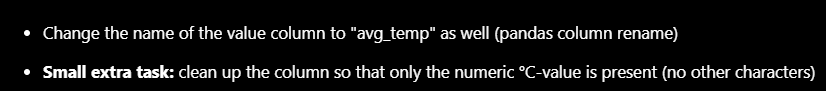

In [747]:
# BASIC TASK
# First we load the dataframe.
url = "https://en.wikipedia.org/wiki/List_of_countries_by_average_yearly_temperature"
page = requests.get(url)

# Turn the URL into a dataframe.
data = pd.read_html(url)

# Take the first table (the data we want)
df = data[0]

# Drop the first column
df = df.drop('Unnamed: 0', axis=1)

# Renaming the values column to 'avg_temp'
df.rename(columns={'Temperature (°C)': 'avg_temp'}, inplace=True)

In [748]:
# SMALL EXTRA TASK

# Applying the function that gets rid of unwanted values.
df['avg_temp'] = df['avg_temp'].apply(temperature_splitter)
df

,Country,avg_temp
0,Burkina Faso,30.40
1,Mali,29.21
2,Aruba,29.17
3,Senegal,28.90
4,Mauritania,28.82
...,...,...
229,Mongolia,1.07
230,Russia,−3.79
231,Canada,−4.03
232,Svalbard and Jan Mayen,−6.78


---

### Employment Table

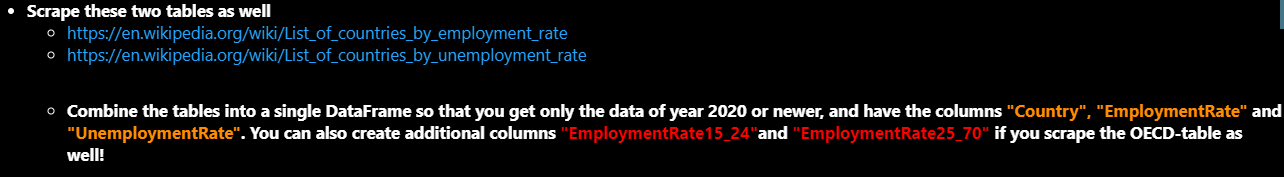

In [749]:

# Loading the website
url = "https://en.wikipedia.org/wiki/List_of_sovereign_states_by_employment_rate"
page = requests.get(url)

# Turn the URL into a dataframe.
data = pd.read_html(url)

# Take the first table of the page to select the data we want.
df_employment = data[0]

# Applying a function that gets rid of unwanted extra characters.
df_employment['Year'] = df_employment['Year'].apply(year_splitter)

# Now we can turn the column into an integer datatype.
df_employment['Year'] = df_employment['Year'].astype(int)

# Filtering out all values older than 2020
df_employment = df_employment[df_employment['Year'] >= 2020]

# Dropping the columns we don't need
df_employment = df_employment.drop(['Ages', 'Year', 'Source'], axis=1)

# Applying the function that get's rid of asterisks.
df_employment['Country'] = df_employment['Country'].apply(country_splitter)

# We're finished!
df_employment


,Country,Rate (%)
0,Iceland,86.9
1,Netherlands,80.8
2,Switzerland,80.1
3,New Zealand,79.2
4,Japan,78.0
5,Norway,77.5
6,Germany,76.8
7,Denmark,76.5
8,Sweden,76.0
9,United Kingdom,75.5


--- 


### Unemployment Rate Table

In [750]:
# UNEMPLOYMENT RATE TABLE
url = "https://en.wikipedia.org/wiki/List_of_countries_by_unemployment_rate"
page = requests.get(url)

# Turn the URL into a dataframe.
data = pd.read_html(url)

# Take the first table (the data we want)
df_unemployment = data[0]

# Getting rid of asterisks in the country column
df_unemployment['Country'] = df_unemployment['Country'].apply(country_splitter)

# Let's rename this. It will make the code unreadable and long.
df_unemployment.rename(columns={'Source/date of information': 'Year'}, inplace=True)

# There is a wide variety of random stuff before the year is given for each country value.
# Let's parse out the year from all that noise.
df_unemployment['Year'] = df_unemployment['Year'].apply(year_converter)

# Now we have the year, we can convert the column to integer.
df_unemployment['Year'] = df_unemployment['Year'].astype(int)

# Then, we filter out ALL VALUES older than 2020.
df_unemployment = df_unemployment[df_unemployment['Year'] >= 2020]

# Dropping the columns we don't need
df_unemployment = df_unemployment.drop('Year', axis=1)

# Finished product looks ok!
df_unemployment

,Country,Unemployment rate (%)
0,Afghanistan,14.39
1,Albania,8.80
2,Algeria,12.70
4,Andorra,1.50
5,Angola,8.50
...,...,...
218,Vietnam,2.06
219,U.S. Virgin Islands,13.30
221,Yemen,13.60
222,Zambia,13.00


In [751]:
# Before we join, let's replace some of these names to match the requirements for the exercise.
df_unemployment.rename(columns={'Unemployment rate (%)': 'Unemployment Rate'}, inplace=True)
df_employment.rename(columns={'Rate (%)': 'Employment Rate'}, inplace=True)

# Merging/joining the two datasets.
df_merge = df_unemployment.merge(df_employment, left_on ='Country', right_on="Country", how="left")




In [752]:
# Hmm, it seems that there are a lot of missing entries here. I think that's because they haven't 
# really updated these tables as much as they could have. We filtered out all anything older than
# 2020, which might have left alot of these numbers out.

# Fun practice though. Especially with using lots of functions to make it work right! If you have 
# any suggestions on how I could have sped this up, feel free to give feedback!
df_merge

,Country,Unemployment Rate,Employment Rate
0,Afghanistan,14.39,NaN
1,Albania,8.80,NaN
2,Algeria,12.70,NaN
3,Andorra,1.50,NaN
4,Angola,8.50,NaN
...,...,...,...
191,Vietnam,2.06,NaN
192,U.S. Virgin Islands,13.30,NaN
193,Yemen,13.60,NaN
194,Zambia,13.00,NaN


<h4><b>6. Simple merging:</b> Download <u><b>coffee_sales.csv</b></u> and <b><u>temperatures_fixed.csv</u></b> from Moodle.<b></h4>
<p>Use merging to combine these files into one DataFrame, containing the coffee sales data and the corresponding temperature –data. (merge(), see materials for examples)</p>


<span style="color: red;"><b>Use left join, and coffee sales as the first DataFrame!</b></span>

In [753]:
# BASIC TASK
# Loading the datasets and attaching them to variables
coffee = pd.read_csv("coffee_sales.csv")
temperatures = pd.read_csv("temperatures_fixed.csv")

# Merging the two datasets.
df_merge = coffee.merge(temperatures, left_on ='Date', right_on="Date", how="left")

In [754]:
df_merge.head(5)

,Date,Sales,Target_sales,Total_expenses,Temperature (C)
0,1.10.2012,122,90,76,19.822917
1,1.10.2012,123,90,45,19.822917
2,2.10.2012,107,90,36,19.020602
3,3.10.2012,94,100,21,15.820139
4,4.10.2012,182,80,54,15.110648


<b>Extra task: </b> Do the same but with <b>temperatures_unfixed.csv</b> instead. Remember <b>groupby()</b> before attempting merging! 

<b>Also, you might want to remove some of the columns before grouping data => <span style="color: red;">Summary + Hour</span>. </b>

<span><i>You can also try to merge the DataFrames so that the Summary –of the weather is also added. For this, you probably need to figure out first how to determine the "average" Summary for each day (extra challenge!).</i></span>


In [755]:
# EXTRA TASK
# Let's try to perform the extra challenge task!

# Loading the dataset
temperatures = pd.read_csv("temperatures_unfixed.csv")
temperatures.head(10)

# OK! A couple of unneeded columns. We'll need to use a groupby that aggregates the average temperature 

,Summary,Temperature (C),Date,Hour
0,Partly Cloudy,9.472222,31.3.2006,22
1,Partly Cloudy,9.355556,31.3.2006,23
2,Mostly Cloudy,9.377778,1.4.2006,0
3,Partly Cloudy,8.288889,1.4.2006,1
4,Partly Cloudy,9.222222,1.4.2006,3
5,Partly Cloudy,7.733333,1.4.2006,4
6,Partly Cloudy,8.772222,1.4.2006,5
7,Partly Cloudy,10.822222,1.4.2006,6
8,Partly Cloudy,16.016667,1.4.2006,8
9,Partly Cloudy,17.144444,1.4.2006,9


In [756]:
# Here, we use a groupby that takes the average of each temperature by date.
groupby_temp = temperatures.groupby(['Date'])[['Temperature (C)']].mean().round(2)
groupby_temp.sort_values('Date', ascending=False)

,Temperature (C)
Date,
9.9.2016,22.73
9.9.2015,13.58
9.9.2014,20.10
9.9.2013,16.08
9.9.2012,21.73
...,...
1.1.2010,7.81
1.1.2009,-4.85
1.1.2008,-5.66


In [757]:
import statistics

# For the summary, I think it is the most intuitive if we just take the most common summary value for 
# for that day as the value. In other words, that is the 'mode' of the date.

# Here we make another groupby, but this time, we use a lambda function.
# What this does, it is takes the most common 'Summary' value for that day for the groupby.
groupby_summary = temperatures.groupby(['Date'])[['Summary']].agg(lambda x: x.mode().iloc[0])
groupby_summary.sort_values('Date', ascending=False)

,Summary
Date,
9.9.2016,Partly Cloudy
9.9.2015,Partly Cloudy
9.9.2014,Partly Cloudy
9.9.2013,Mostly Cloudy
9.9.2012,Clear
...,...
1.1.2010,Overcast
1.1.2009,Overcast
1.1.2008,Foggy


In [758]:
# Now we merge these two groupbys first.
df_merge = groupby_summary.merge(groupby_temp, left_on ='Date', right_on="Date", how="left")
df_merge


,Summary,Temperature (C)
Date,,
1.1.2006,Mostly Cloudy,4.07
1.1.2007,Overcast,3.81
1.1.2008,Foggy,-5.66
1.1.2009,Overcast,-4.85
1.1.2010,Overcast,7.81
...,...,...
9.9.2012,Clear,21.73
9.9.2013,Mostly Cloudy,16.08
9.9.2014,Partly Cloudy,20.10


In [759]:
# And one more final merge
df_merge = df_merge.merge(coffee, left_on="Date", right_on="Date", how="left")
df_merge

,Date,Summary,Temperature (C),Sales,Target_sales,Total_expenses
0,1.1.2006,Mostly Cloudy,4.07,NaN,NaN,NaN
1,1.1.2007,Overcast,3.81,NaN,NaN,NaN
2,1.1.2008,Foggy,-5.66,NaN,NaN,NaN
3,1.1.2009,Overcast,-4.85,NaN,NaN,NaN
4,1.1.2010,Overcast,7.81,NaN,NaN,NaN
...,...,...,...,...,...,...
4015,9.9.2012,Clear,21.73,NaN,NaN,NaN
4016,9.9.2013,Mostly Cloudy,16.08,159.0,100.0,41.0
4017,9.9.2014,Partly Cloudy,20.10,211.0,200.0,33.0
4018,9.9.2015,Partly Cloudy,13.58,NaN,NaN,NaN


<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex56coffee.jpg" width="450" />


<h2><b>Advanced extra tasks for extra points (varying challenges, some require Googling):</b></h2>

<ul>
<li><b>1. Download the "complex.json" –file from Moodle.</b> Note that this data is fairly complex (i.e. heavily nested). Use json_normalize and other needed methods to convert this data into a workable DataFrame.</li>
</ul>

In [ ]:
# code for the advanced extra task

# Creating a load response with JSON module.
json_file = open('complex.json')
response_raw = json_file.read()
json_file.close()
response = json.loads(response_raw)

# Normalizing the dataframe.
df = pd.json_normalize(response)
df 

,id,brand,model,year,price,ownership.company,ownership.acquired,ownership.payment_info.credit_card,ownership.payment_info.iban
0,1,Ford,F250,1997,72213,Johns and Sons,24/10/2017,jcb,SA47 315V KYTA 8FVT NCGN MM7G
1,2,Dodge,Grand Caravan,1999,42370,"Crist, Hyatt and Leannon",7/6/2020,instapayment,FR74 8157 1767 53I2 VRAN ZMIB U11
2,3,Audi,A5,2011,19191,Bosco and Sons,23/11/2018,jcb,LB32 4989 VCVZ S5BZ X2CT JKG3 QRAW
3,4,Hyundai,Veracruz,2012,21956,Haley Inc,5/6/2016,bankcard,BE62 4961 0596 5774
4,5,Chevrolet,TrailBlazer,2009,53066,"Zulauf, Nolan and Franecki",14/1/2021,jcb,FR11 1768 5506 10IU QVPN XU2H O88
...,...,...,...,...,...,...,...,...,...
95,96,Hyundai,Elantra,1997,38400,Keebler and Sons,26/6/2019,visa-electron,RS34 1571 2547 8662 4201 18
96,97,Mercury,Grand Marquis,1996,27284,Wunsch-Ernser,9/11/2019,mastercard,AD85 4944 9836 X0YY JZAF NIXH
97,98,GMC,Safari,1996,17723,Ondricka-Schuster,17/7/2016,jcb,FR22 8203 4892 75GI 8YFM NAXR B47
98,99,Dodge,Ram Van 1500,2000,32892,Heathcote-Gleichner,21/4/2016,jcb,SA43 49ZA FH7V 20XN BYDW ROEX


<ul>
<li><b>2. Load the "simple.json" –file without pandas, and try to get the average price with plain Python. <b>(DON'T USE AI HERE)</b></li>
</ul>


In [ ]:
# This is ujson, a solution I've found from StackOverflow.
# This method is apparently quite good for giant files (Think 30gb's+ , more than Pandas allows.)
# I am not sure if using this modules is 

import ujson
with open("simple.json") as f:
    file_contents = ujson.load(f)

file_contents

[{'id': 1,
  'brand': 'Chrysler',
  'model': 'Voyager',
  'year': 2001,
  'owned_by': 'Wolff-Trantow',
  'acquired': '28/12/2016',
  'price': 11565},
 {'id': 2,
  'brand': 'Volkswagen',
  'model': 'Jetta',
  'year': 1995,
  'owned_by': 'Schuppe, Pfeffer and Klein',
  'acquired': '20/4/2016',
  'price': 52431},
 {'id': 3,
  'brand': 'Porsche',
  'model': 'Cayenne',
  'year': 2005,
  'owned_by': 'Mante Group',
  'acquired': '11/6/2020',
  'price': 75552},
 {'id': 4,
  'brand': 'Porsche',
  'model': '928',
  'year': 1994,
  'owned_by': 'Wisozk Group',
  'acquired': '17/6/2019',
  'price': 30331},
 {'id': 5,
  'brand': 'Mercedes-Benz',
  'model': 'SL-Class',
  'year': 2007,
  'owned_by': 'Schiller-Littel',
  'acquired': '20/7/2018',
  'price': 62385},
 {'id': 6,
  'brand': 'Audi',
  'model': 'A6',
  'year': 2008,
  'owned_by': 'Bashirian Inc',
  'acquired': '8/4/2020',
  'price': 76249},
 {'id': 7,
  'brand': 'Lincoln',
  'model': 'Continental',
  'year': 1988,
  'owned_by': 'Hilll, Osinsk

In [762]:
# PROOF. No Pandas!
type(file_contents)

list

<ul>
<li><b>3. Download the "complex.xml" file from Moodle, and create a DataFrame out of it.</b></li>
<ul>
    <li><b>Note:</b> using pandas.read_xml() would otherwise work, but it ignores the "ownership" –field. You'll have to find another way to get this data into your DataFrame as well!</li>
</ul>
</ul>

In [763]:
# code for the advanced extra task, you can also create a separate notebook for this 
# (might be a better idea, since a new dataset always adds quite much new code)

# A self-made solution!

# Our plan: 
# 1. Read the xml file.
# REPEATABLE
# 2. Check if a column has entirely missing values.
# 3. If it does contain a column like that, drop the column.
# 4. Then make a new dataframe (with a different name.) Then drill further using xpath into that column (because it's nested.)
# 5. Check again if a column has missing values, if so, go to 3.
# END
# 6. Concatinate all the pd dataframes together. 
# 7. Verify the first couple rows of the XML file to ensure it's correct.

df = pd.read_xml("complex.xml")
df

# The ownership column has entirely missing values.

,id,brand,model,year,ownership,price
0,1,Mazda,B-Series Plus,1994,NaN,69221
1,2,Ford,F350,2006,NaN,13859
2,3,BMW,7 Series,2012,NaN,78125
3,4,Subaru,Baja,2004,NaN,32941
4,5,Audi,S6,2007,NaN,46761
...,...,...,...,...,...,...
95,96,Lexus,IS,2004,NaN,79409
96,97,Oldsmobile,Bravada,2001,NaN,61308
97,98,Dodge,Ram 2500 Club,1996,NaN,12101
98,99,Jeep,Wrangler,2007,NaN,74912


In [764]:
# We get rid of the values, or it will stack the rows improperly with the concat.
df = df.drop('ownership', axis=1)

# We then drill into the ownership value by using the same code but with the xpath attribute.
ownership = pd.read_xml("complex.xml", xpath = "car/ownership")
ownership

# Looks like we have to drill a little further! Since again, there's a missing values column.

,company,acquired,payment_info
0,Mueller-VonRueden,25/3/2020,NaN
1,"Simonis, Graham and Veum",6/4/2020,NaN
2,Hammes LLC,25/12/2017,NaN
3,"MacGyver, Oberbrunner and McGlynn",2/6/2019,NaN
4,"Hand, Johnston and Hickle",12/10/2016,NaN
...,...,...,...
95,Lesch LLC,24/12/2018,NaN
96,Swaniawski-Fahey,31/3/2021,NaN
97,"Boyle, Bins and Hand",14/2/2017,NaN
98,Frami and Sons,1/1/2019,NaN


In [765]:
# Dropping the column
ownership = ownership.drop('payment_info', axis=1)

# Looks like we don't need to drill further, perfect!
payment = pd.read_xml("complex.xml", xpath ="car/ownership/payment_info")
payment

# Now we're going to concatinate.

,credit_card,iban
0,jcb,LU43 964Q PJUD Z9WI JVSR
1,diners-club-enroute,AE82 5889 6103 2911 2983 729
2,jcb,AZ52 PNUH TWPT YQY9 RMLE BMXO 4JIT
3,mastercard,FR22 5863 0754 268V RGIQ GHX5 Y27
4,jcb,LT37 9834 6062 9512 0523
...,...,...
95,jcb,FR64 3740 9590 01ZO OCUS 3G4U N18
96,switch,FR20 8397 0045 00LM TIZG K8XG Y85
97,instapayment,LT97 1330 9495 1788 8021
98,americanexpress,FR29 9014 0050 39DG BF8H M8BB R59


In [766]:
# And viola! 
df = pd.concat([df,ownership,payment], axis=1)
df

# What would be very neat is to make a custom function that does all of this nesting automatically too. 
# You would make a loop with the condition that if a column has ONLY null values, then make it drill further!


,id,brand,model,year,price,company,acquired,credit_card,iban
0,1,Mazda,B-Series Plus,1994,69221,Mueller-VonRueden,25/3/2020,jcb,LU43 964Q PJUD Z9WI JVSR
1,2,Ford,F350,2006,13859,"Simonis, Graham and Veum",6/4/2020,diners-club-enroute,AE82 5889 6103 2911 2983 729
2,3,BMW,7 Series,2012,78125,Hammes LLC,25/12/2017,jcb,AZ52 PNUH TWPT YQY9 RMLE BMXO 4JIT
3,4,Subaru,Baja,2004,32941,"MacGyver, Oberbrunner and McGlynn",2/6/2019,mastercard,FR22 5863 0754 268V RGIQ GHX5 Y27
4,5,Audi,S6,2007,46761,"Hand, Johnston and Hickle",12/10/2016,jcb,LT37 9834 6062 9512 0523
...,...,...,...,...,...,...,...,...,...
95,96,Lexus,IS,2004,79409,Lesch LLC,24/12/2018,jcb,FR64 3740 9590 01ZO OCUS 3G4U N18
96,97,Oldsmobile,Bravada,2001,61308,Swaniawski-Fahey,31/3/2021,switch,FR20 8397 0045 00LM TIZG K8XG Y85
97,98,Dodge,Ram 2500 Club,1996,12101,"Boyle, Bins and Hand",14/2/2017,instapayment,LT97 1330 9495 1788 8021
98,99,Jeep,Wrangler,2007,74912,Frami and Sons,1/1/2019,americanexpress,FR29 9014 0050 39DG BF8H M8BB R59


---

<ul>
    <li><b>4. Try out Selenium on a site that cannot be scraped with traditional methods. You can use this tutorial as the starting point:</b></li>
    <ul>
        <li><a href="https://www.toptal.com/python/web-scraping-with-python">https://www.toptal.com/python/web-scraping-with-python</a></li>
    </ul>
</ul>

In [767]:
# code for the advanced extra task, you can also create a separate notebook for this 
# (might be a better idea, since a new dataset always adds quite much new code)

<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_5/ex5charts.jpg" width="600" />

<b>5. Extra challenging advanced task: <span style="color: red;">integrating data sources</span></b>

<ul>
<li><b>Integrate two or more datasets into one matching dataset (pandas DataFrame), but use any datasets you can find in Kaggle.com instead of the previous coffee sales + temperature -datasets</b></li>
<br />
<ul>
<li>Find two or more datasets (Kaggle.com etc.) that have something in common and can be used for merging. </li>
</ul>

<br />
<ul>
<li><b>Typical common columns:</b></li>
<ul>
<li>Coordinates (lat/lng etc.)</li>
<li>Years, months</li>
<li>reference ids (e.g. product id -> product data)</li>
</ul>
</ul>

<br />
<ul>
<li><b>You can use pandas.merge() in order to combine DataFrames</b></li>
<ul>
<li>When combining DataFrames, make sure that the merge doesn’t mess up your data</li>
<li><b>Note:</b> merge can often create way too many extra rows depending on the merging parameters</li>

</ul>
</ul>

<br />
<ul>
<li><b>This exercise can provide even large amounts of points, depending on difficulty. Aspects that affect grading:</b></li>
<ul>
<li>Amount of datasets</li>
<li>Difficulty of the datasets</li>
<li>Using different data formats all at once (XML, JSON, CSV etc.)</li>
<li>Other techniques used to add data: web scraping, data APIs etc.</li>
</ul>
</ul>


</ul>

In [768]:
# this exercise is probably better to do in a separate Jupyter notebook